# Taller 2 Cálculo Numérico

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, fixed_quad, tplquad
from scipy.special import roots_legendre, hermite, factorial

# 1.
Supongamos que una onda plana de longitud de onda $\lambda$, es bloqueada por un objeto con un borde recto, representado por la línea continua en la parte inferior de esta figura:

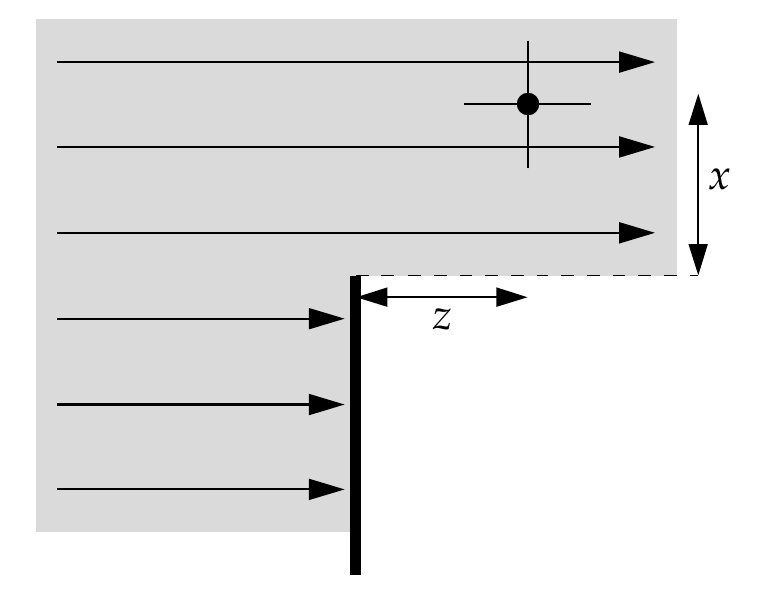

La onda se difractará en el borde y la intensidad resultante en la posición $(x, z)$ (marcada por el punto) está dada por la teoría de difracción en el campo cercano como:

$$ I = \frac{I_0}{8} \left( [2C(u) + 1]^2 + [2S(u) + 1]^2 \right)$$

donde:
- $$I_0 = \text{intensidad de la onda antes de la difracción} $$
- $$u = x \sqrt{\frac{2}{\lambda z}}$$
- $$ C(u) = \int_{0}^{u} \cos \left(\frac{1}{2} \pi t^2 \right) dt $$ 
- $$ S(u) = \int_{0}^{u} \sin \left(\frac{1}{2} \pi t^2 \right) dt $$

Grafique $I/I_0$ como función de $x$ en el rango $-5\,\text{m}$ a $5\,\text{m}$ para el caso de una onda sonora con longitud de onda $\lambda = 1\,\text{m}$ y distancia de medición $z = 3\,\text{m}$ después del borde recto.

**Nota**: Utilice cuadratura gaussiana con 50 puntos.


In [2]:
# Parámetros dados
lambda_ = 1.0  # longitud de onda en metros
z = 3.0        # distancia de medición en metros
x_range = np.linspace(-5, 5, 500)  # rango de x en metros

In [3]:
def gauss_quad_standard(func,a,b,n):
    """
    Calcula la integral de una función en el intervalo [a, b]
    utilizando cuadratura gaussiana.

    Parameters:
    - func: La función a integrar.
    - n: Número de puntos para la cuadratura (grado del polinomio de Legendre).

    Returns:
    - Aproximación de la integral.
    """
    # Obtener raíces y pesos del polinomio de Legendre
    t, w = roots_legendre(n)
    x = (b - a) / 2 * t + (a + b) / 2
    # Evaluar la suma ponderada
    integral = np.sum(w * func(x))*(b-a)/2
    return integral

In [4]:
# Definir las integrales de Fresnel C(u) y S(u)
def fresnel_c(u):
    integrand = lambda t: np.cos(0.5 * np.pi * t**2)
    return gauss_quad_standard(integrand,0,u,50)

def fresnel_s(u):
    integrand = lambda t: np.sin(0.5 * np.pi * t**2)
    return gauss_quad_standard(integrand,0,u,50)

In [5]:
# Calcular I/I0 para cada x en x_range
I_over_I0 = []
for x in x_range:
    u = x * np.sqrt(2 / (lambda_ * z))
    C_u = fresnel_c(u)
    S_u = fresnel_s(u)
    intensity = ( (2*C_u + 1)**2 + (2*S_u + 1)**2 ) / 8
    I_over_I0.append(intensity)

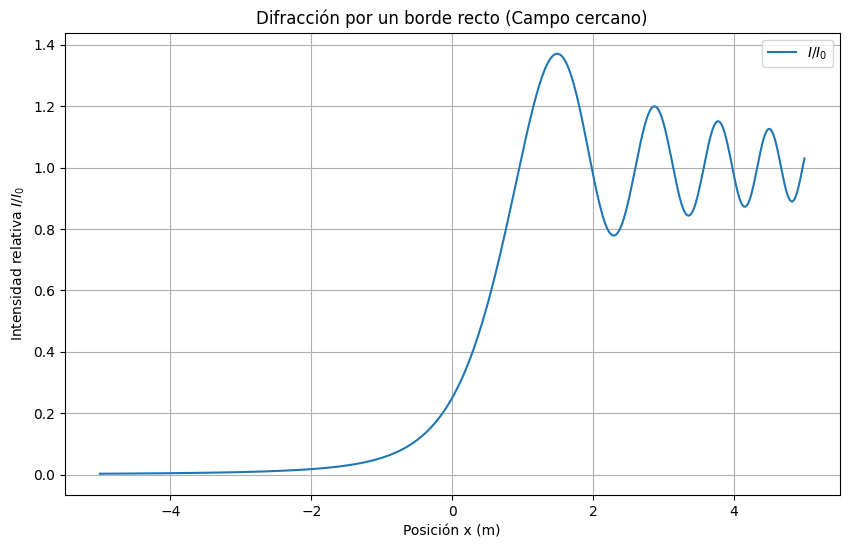

In [6]:
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(x_range, I_over_I0, label=r'$I/I_0$')
plt.xlabel('Posición x (m)')
plt.ylabel(r'Intensidad relativa $I/I_0$')
plt.title('Difracción por un borde recto (Campo cercano)')
plt.grid()
plt.legend()
plt.show()

## Utilicemos scipy

In [7]:
# Definir las integrales de Fresnel C(u) y S(u)
def fresnel_c(u):
    integrand = lambda t: np.cos(0.5 * np.pi * t**2)
    return fixed_quad(integrand, 0, u,n=50)[0]

def fresnel_s(u):
    integrand = lambda t: np.sin(0.5 * np.pi * t**2)
    return fixed_quad(integrand, 0, u,n=50)[0]

In [8]:
# Calcular I/I0 para cada x en x_range
I_over_I0 = []
for x in x_range:
    u = x * np.sqrt(2 / (lambda_ * z))
    C_u = fresnel_c(u)
    S_u = fresnel_s(u)
    intensity = ( (2*C_u + 1)**2 + (2*S_u + 1)**2 ) / 8
    I_over_I0.append(intensity)

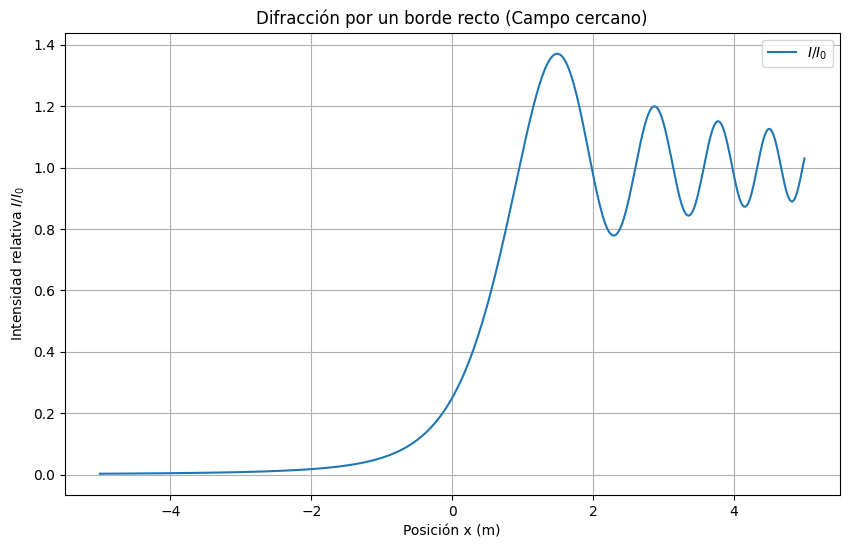

In [9]:
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(x_range, I_over_I0, label=r'$I/I_0$')
plt.xlabel('Posición x (m)')
plt.ylabel(r'Intensidad relativa $I/I_0$')
plt.title('Difracción por un borde recto (Campo cercano)')
plt.grid()
plt.legend()
plt.show()

# 2.
Un péndulo físico en el regimen de pequeñas oscilaciones tiene un periodo de:

$$
P_0=2\pi \sqrt{\frac{I_0}{mgb}}
$$

con b la distancia del pivote al centro de masa. Cuando las oscilaciones no son pequeñas, podemos encontrar una expresión para el periodo de la siguiente forma:


La energia de un péndulo físico viene dada por:

$$
E=\frac{I_0\omega^2}{2}+mgb(1-\cos \theta)
$$

En el punto más alejado de su posición de equilibrio, su energía es solo potencial y viene dada por:

$$
Ep = mgb(1-\cos \theta_0),
$$

Igualando ambas expresiones tenemos que:

$$
mgb(1-\cos \theta_0)=\frac{I_0\omega^2}{2}+mgb(1-\cos \theta)
$$

Integrando la ecuación respecto a $\theta$ y realizando la sustitución:

$\sin \phi = \frac{\sin \frac{\theta}{2}}{\sin \frac{\theta_0}{2}}$ y  $k = \sin \frac{\theta_0}{2}$, se puede encontrar  que el periodo de oscilación, viene dado en terminos de  la integral elíptica completa de primera especie:


$$
P = \frac{2P_0}{\pi} \int _0^{\pi/2} \frac{\mathrm{d\phi}}{\sqrt{1-k^2\sin^2\phi}}
$$

donde,  $P_0$ es el periodo de las oscilaciones pequeñas.

Determinar el periodo de oscilación de un péndulo utilizando cuadratura gaussiana. 

**Nota:** Suponga los párametros iniciales del pendulo.

In [10]:
# Parámetros del péndulo
I0 = 1.0       # Momento de inercia (kg·m²)
m = 1.0        # Masa (kg)
g = 9.81       # Gravedad (m/s²)
b = 0.7        # Distancia al centro de masa (m)
theta0_deg = 45  # Amplitud inicial en grados
theta0 = np.radians(theta0_deg)  # Convertir a radianes

# Periodo para oscilaciones pequeñas P0
P0 = 2 * np.pi * np.sqrt(I0 / (m * g * b))

# Calcular k 
k = np.sin(theta0 / 2)

# Función integrando para la integral elíptica
def integrand(phi, k):
    return 1 / np.sqrt(1 - (k * np.sin(phi))**2)

# Calcular la integral elíptica completa de primera especie
integral = fixed_quad(integrand, 0, np.pi/2, args=(k,),n=5)[0]

# Periodo general P
P = (2 * P0 / np.pi) * integral
print(f"Periodo general (P): {P:.4f} s")

Periodo general (P): 2.4936 s


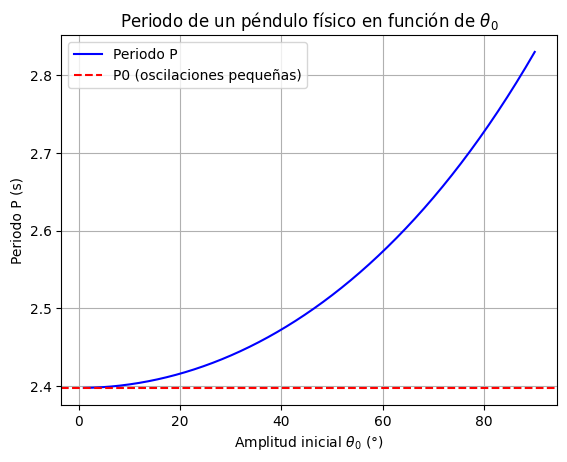

In [11]:
theta0_deg_range = np.linspace(1, 90, 50)  # Amplitudes de 1° a 90°
P_values = []

for theta0_deg in theta0_deg_range:
    theta0 = np.radians(theta0_deg)
    k = np.sin(theta0 / 2)
    integral = fixed_quad(integrand, 0, np.pi/2, args=(k,),n=4)[0]
    P = (2 * P0 / np.pi) * integral
    P_values.append(P)

plt.plot(theta0_deg_range, P_values, 'b-', label='Periodo P')
plt.axhline(y=P0, color='r', linestyle='--', label='P0 (oscilaciones pequeñas)')
plt.xlabel(r'Amplitud inicial $\theta_0$ (°)')
plt.ylabel('Periodo P (s)')
plt.title(r'Periodo de un péndulo físico en función de $\theta_0$')
plt.legend()
plt.grid()
plt.show()

# 3.
La cantidad de masa transportada por una tuberia durante un periodo de tiempo se puede calcular como

$$M = \int_{t_1}^{t_2} Q(t) c(t) \; dt$$

siendo M (masa en $mg$), $Q(t)$ el caudal ($m^3/min$) y $c(t)$ concentración ($mg/m^3$). Sean las siguientes representaciones funcionales:

$$Q(t) = 9 + 5 \cos^2 (0.4t)$$
$$c(t) = 5e^{-0.5 t} + 2 e^{0.15 t}$$

Entre $t_1 = 2$ y $t_2 = 8$ min
- Haga un gráfico del caudal y la concentración en función del tiempo.
- Determine la masa transportada usando el método de cuadratura Gaussiana adaptativa `quad`.

In [12]:
# Definir las funciones Q(t) y c(t)
def Q(t):
    return 9 + 5 * (np.cos(0.4 * t))**2

def c(t):
    return 5 * np.exp(-0.5 * t) + 2 * np.exp(0.15 * t)

# Intervalo de tiempo
t1 = 2
t2 = 8
t = np.linspace(t1, t2, 500)  # Puntos para graficar

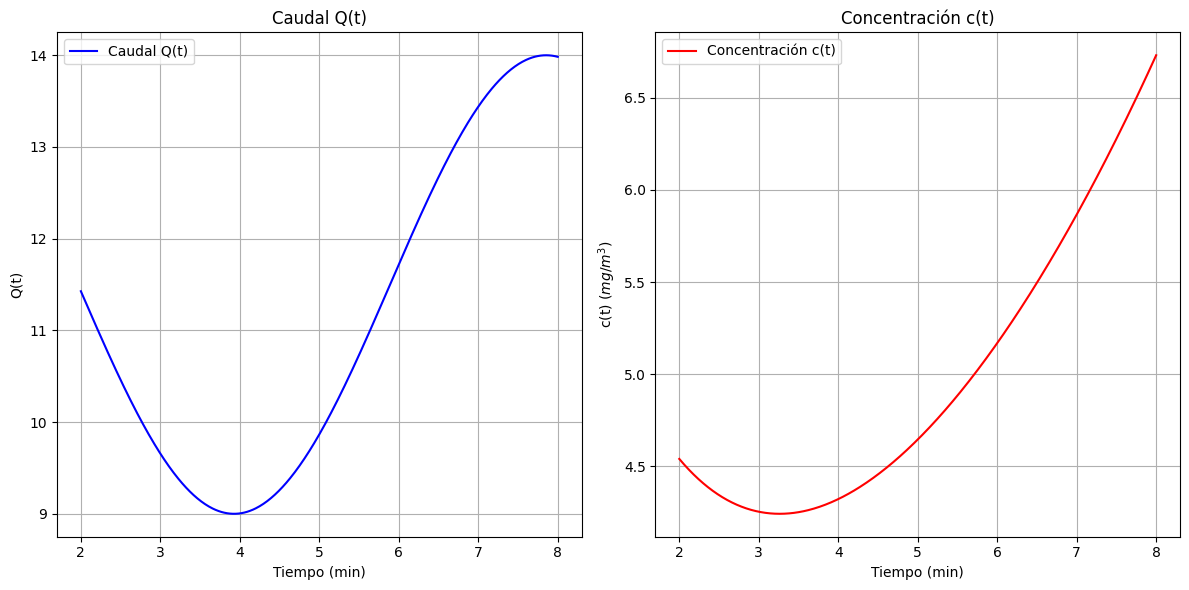

In [13]:
# Graficar Q(t) y c(t)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t, Q(t), 'b-', label='Caudal Q(t)')
plt.xlabel('Tiempo (min)')
plt.ylabel('Q(t)')
plt.title('Caudal Q(t)')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t, c(t), 'r-', label='Concentración c(t)')
plt.xlabel('Tiempo (min)')
plt.ylabel(r'c(t) ($mg/m^3$)')
plt.title('Concentración c(t)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# Función integrando para la masa M: Q(t) * c(t)
def integrando(t):
    return Q(t) * c(t)

# Calcular la masa transportada usando quad
M, error = quad(integrando, t1, t2)
print(f"Masa transportada M: {M:.4f} mg")
print(f"Error estimado: {error:.4e}")

Masa transportada M: 335.9625 mg
Error estimado: 3.7299e-12


# 4.
En unidades donde todas las constantes son 1, la función de onda del nivel de energía $n$-ésimo del oscilador armónico cuántico unidimensional está dada por:

$$\psi_{n}(x)=\frac{1}{\sqrt{2^{n}n!\sqrt{\pi}}}\,e^{-x^{2}/2}\,H_{n}(x)$$

para $n=0$ a $\infty$, donde $H_{n}(x)$ es el polinomio de Hermite de orden $n$.

Los polinomios de Hermite satisfacen la relación de recurrencia:

$$H_{n+1}(x)=2xH_{n}(x)-2nH_{n-1}(x)$$

con los primeros dos polinomios:
$$H_{0}(x)=1$$
$$H_{1}(x)=2x$$

- Implemente una función $H(n,x)$ que calcule $H_{n}(x)$ para cualquier $x$ y $n \geq 0$. 
- Grafique las funciones de onda para $n=0,1,2,3$ en el rango $x \in [-4,4] $.
- Grafique $\psi_{30}(x)$ en el rango $x=-10$ a $10$, asegurando que el cálculo sea eficiente.
- Calcule la incertidumbre cuántica, la cual se puede cuantificar mediante la posición cuadrática media:

$$\sqrt{\braket{x^{2}}} = \left(\int_{-\infty}^{\infty}x^{2}|\psi_{n}(x)|^{2}\,dx\right)^{1/2}$$


In [15]:
# Función para calcular H_n(x) usando recurrencia
def H(n, x):
    if n < 0 :
        raise ValueError('n no puede ser menor que 0')
    elif n==0:
        return np.ones_like(x)    # H_0(x)
    elif n==1:
        return 2*x  # H_1(x)
    else:
        return 2*x*H(n-1,x)-2*(n-1)*H(n-2,x)

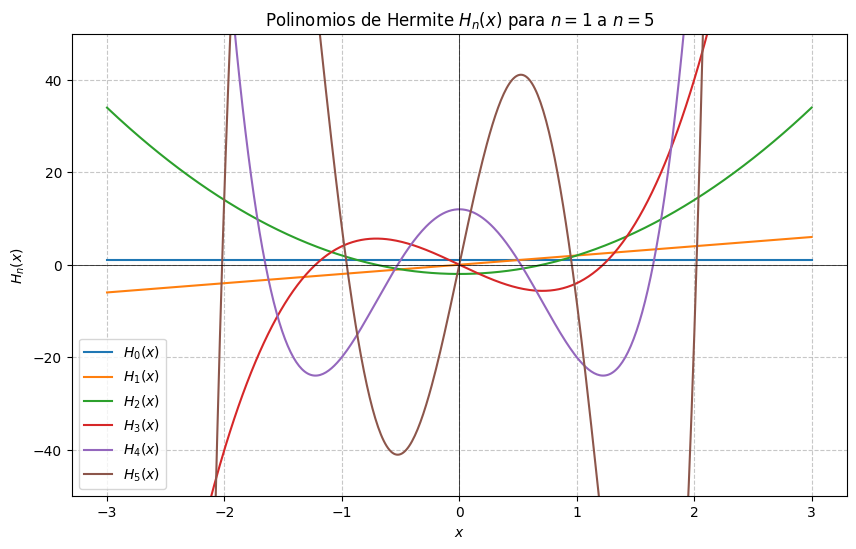

In [16]:
x = np.linspace(-3, 3, 500)
# Graficamos H1(x) a H5(x)
plt.figure(figsize=(10, 6))
for n in range(6):
    y = H(n, x)
    plt.plot(x, y, label=f'$H_{n}(x)$')

# Configuración del gráfico
plt.title('Polinomios de Hermite $H_n(x)$ para $n=1$ a $n=5$')
plt.xlabel('$x$')
plt.ylabel('$H_n(x)$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-50,50)
plt.legend()
plt.show()

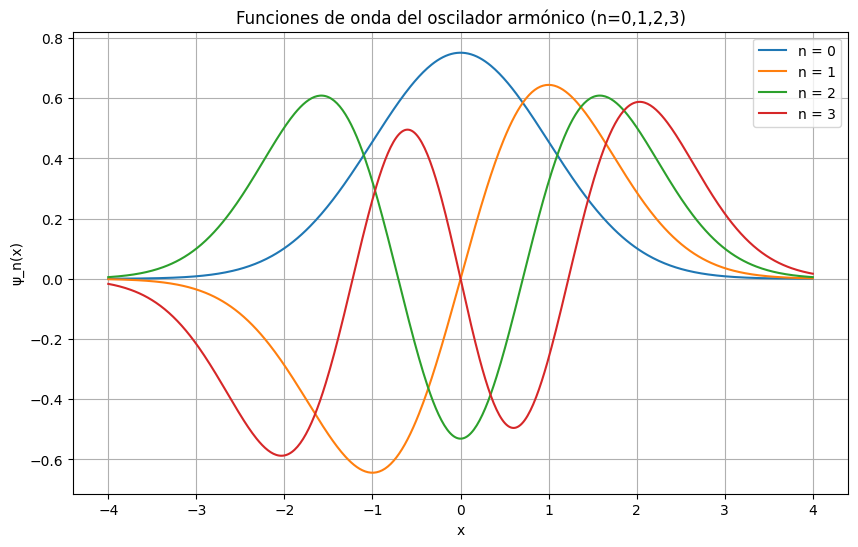

In [ ]:
# Función de onda psi_n(x)
def psi(n, x):
    coeff = 1 / np.sqrt(2**n * factorial(n) * np.sqrt(np.pi))
    return coeff * np.exp(-x**2 / 2) * H(n, x)

# Graficar psi_n(x) para n=0,1,2,3 en x ∈ [-4,4]
x = np.linspace(-4, 4, 500)

plt.figure(figsize=(10, 6))
for n in range(4):
    y = [psi(n, xi) for xi in x]
    plt.plot(x, y, label=f'n = {n}')
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$')
plt.title('Funciones de onda del oscilador armónico (n=0,1,2,3)')
plt.legend()
plt.grid(True)
plt.show()

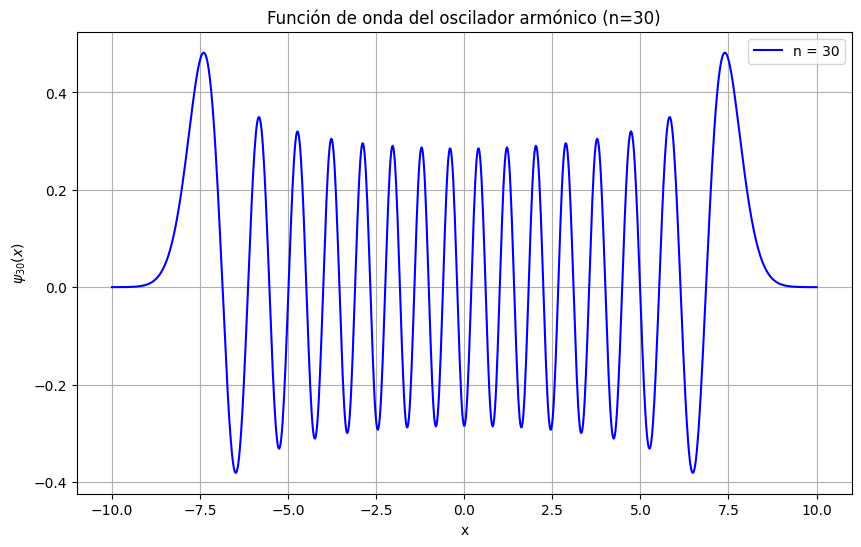

In [18]:
# Graficar psi_30(x) en x ∈ [-10,10] 
x_30 = np.linspace(-10, 10, 1000)
psi_30 = psi(30,x_30)

plt.figure(figsize=(10, 6))
plt.plot(x_30, psi_30, 'b-', label='n = 30')
plt.xlabel('x')
plt.ylabel(r'$\psi_{30}(x)$')
plt.title(r'Función de onda del oscilador armónico (n=30)')
plt.grid()
plt.legend()
plt.show()

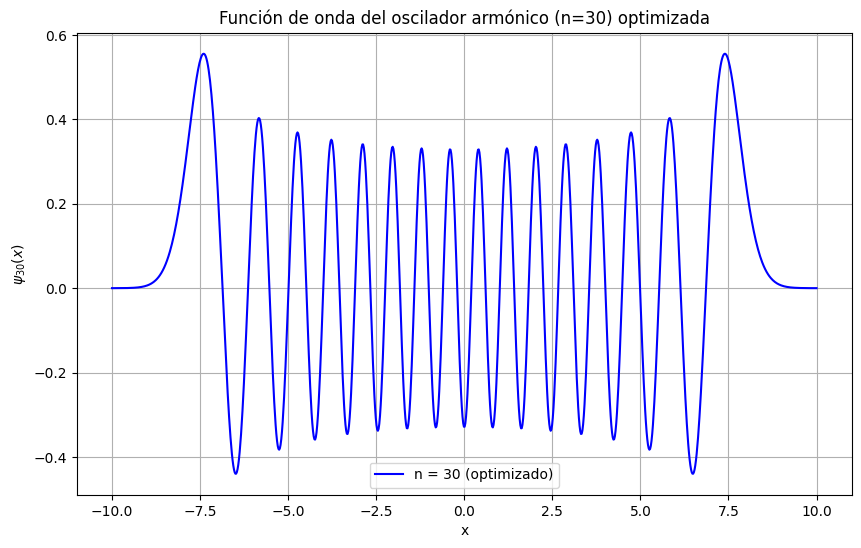

In [19]:
# Mayor eficiencia
def psi_optimized(n, x):
    # Usamos scipy.special.hermite para eficiencia
    Hn = hermite(n)
    coeff = 1.0 / np.sqrt(2**n * factorial(n) * np.pi**0.25)
    return coeff * np.exp(-x**2 / 2) * Hn(x)

# Graficar psi_30(x) de manera optimizada
x_30 = np.linspace(-10, 10, 1000)
psi_30_opt = psi_optimized(30, x_30)

plt.figure(figsize=(10, 6))
plt.plot(x_30, psi_30_opt, 'b-', label='n = 30 (optimizado)')
plt.xlabel('x')
plt.ylabel(r'$\psi_{30}(x)$')
plt.title(r'Función de onda del oscilador armónico (n=30) optimizada')
plt.grid()
plt.legend()
plt.show()

In [20]:
# Calcular la incertidumbre cuántica sqrt(<x^2>)
def integrand(x, n):
    return x**2 * (psi_optimized(n, x))**2

n_values = [0, 1, 2, 3, 4, 5, 30]
uncertainties = []
for n in n_values:
    integral= quad(integrand, -np.inf, np.inf, args=(n,))[0]
    uncertainties.append(np.sqrt(integral))

# Mostrar resultados
for n, unc in zip(n_values, uncertainties):
    print(f"n = {n}: √<x²> = {unc:.4f}")

n = 0: √<x²> = 0.8159
n = 1: √<x²> = 1.4132
n = 2: √<x²> = 1.8244
n = 3: √<x²> = 2.1586
n = 4: √<x²> = 2.4477
n = 5: √<x²> = 2.7060
n = 30: √<x²> = 6.3723


# 5.
La teoría de Planck establece que en el intervalo de frecuencia angular $\omega$ a $\omega + d\omega$, un cuerpo negro radia energía térmica electromagnética por segundo igual a $I(\omega) d\omega$, donde:

$$I(\omega) = \frac{\hbar}{4\pi^2 c^2} \frac{\omega^3}{\left(e^{\hbar\omega/k_B T}-1\right)}$$

con $\hbar$ = constante de Planck reducida ($h/2\pi$), $c$ = velocidad de la luz, $k_B$ = constante de Boltzmann y $T$ = temperatura absoluta.
La energía total por unidad de área radiada por un cuerpo negro es:

$$W = \frac{k_B^4 T^4}{4\pi^2 c^2 \hbar^3} \int_0^\infty \frac{x^3}{e^x - 1} \, dx$$

- Evalúe numéricamente la integral en esta expresión


- Utilizando el valor obtenido para la integral y la ley de Stefan-Boltzmann:

$$W = \sigma T^4$$

calcule el valor de la constante de Stefan-Boltzmann $\sigma$ (en unidades SI) con tres cifras significativas. Compare con el valor conocido.

In [21]:
from scipy.constants import hbar,c,k,sigma

In [22]:
# Función integrando: x^3 / (e^x - 1)
def integrand(x):
    return x**3 / (np.exp(x) - 1)

In [23]:
# Calcular la integral desde 0 hasta infinito
integral, error = quad(integrand, 0, np.inf)
print(f"Valor de la integral: {integral:.6f}")
print(f"Error estimado: {error:.2e}")

Valor de la integral: 6.493939
Error estimado: 2.63e-09


/tmp/ipykernel_3428/3325831789.py:3: RuntimeWarning: overflow encountered in exp
  return x**3 / (np.exp(x) - 1)


Veamos la gráfica del integrando

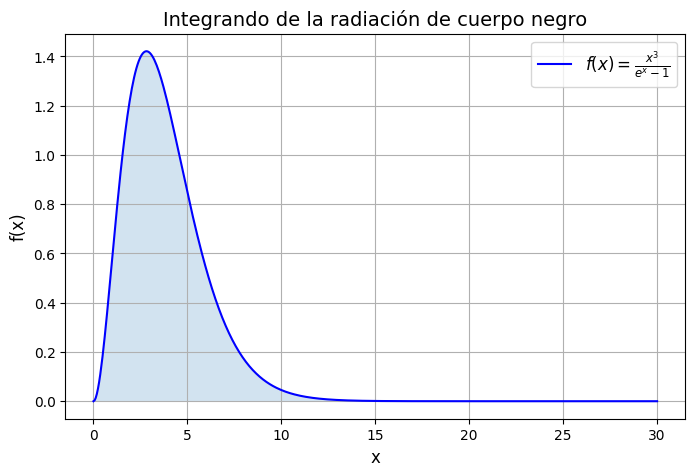

In [24]:
x_values = np.linspace(1e-5, 30, 500)

# Graficamos
plt.figure(figsize=(8, 5))
plt.plot(x_values, integrand(x_values), label=r'$f(x) = \frac{x^3}{e^x - 1}$', color='blue')
plt.fill_between(x_values, integrand(x_values),alpha=0.2)
plt.title('Integrando de la radiación de cuerpo negro', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid()
plt.legend(fontsize=12)
plt.show()

In [25]:
# Calcular la integral desde 0 hasta 30
integral, error = quad(integrand, 0, 30)
print(f"Valor de la integral: {integral:.6f}")
print(f"Error estimado: {error:.2e}")

Valor de la integral: 6.493939
Error estimado: 1.37e-11


In [26]:
# Calcular sigma usando W = sigma * T^4
sigma = (k**4) / (4 * np.pi**2 * c**2 * hbar**3) * integral
print(f"Constante de Stefan-Boltzmann calculada: {sigma:.3e} W m⁻² K⁻⁴")

# Valor conocido de sigma
sigma_known = sigma
print(f"Valor conocido de sigma: {sigma_known:.3e} W m⁻² K⁻⁴")

# Comparación porcentual
error_percent = abs(sigma - sigma_known) / sigma_known * 100
print(f"Error porcentual: {error_percent}%")

Constante de Stefan-Boltzmann calculada: 5.670e-08 W m⁻² K⁻⁴
Valor conocido de sigma: 5.670e-08 W m⁻² K⁻⁴
Error porcentual: 0.0%


# 6.
La función de onda del electrón en estado $3d_0$ ($n=3$, $l=2$, $m=0$) en unidades radiales adimensionales es:

$$\Psi_{320}(r,\theta,\varphi) = \frac{1}{81\sqrt{6\pi}} r^2 e^{-r/3} (3\cos^2\theta - 1)$$


La probabilidad total de localización del electrón debe satisfacer:

$$ \int_0^{2\pi} \int_0^\pi \int_0^\infty  |\Psi_{320}(r,\theta,\varphi)|^2 \, r^2 \, \sin\theta dr  d\theta d\varphi = 1$$

Verifique numéricamente esta normalización.

In [ ]:
# Función para la parte radial: r^6 * exp(-2r/3)
def integrand_radial(r):
    return r**6 * np.exp(-2 * r / 3)

# Función para la parte angular: (3cos²θ - 1)^2 * sinθ
def integrand_angular(theta):
    return (3 * np.cos(theta)**2 - 1)**2 * np.sin(theta)

# Calcular la integral radial
integral_radial= quad(integrand_radial, 0, np.inf)[0]
print(f"Parte radial: {integral_radial:.6f}")

# Calcular la integral angular
integral_angular= quad(integrand_angular, 0, np.pi)[0]
print(f"Parte angular: {integral_angular:.6f}")

# Integral azimutal (trivial)
integral_azimuthal = 2 * np.pi
print(f"Parte azimutal: {integral_azimuthal:.6f}")

# Valor total de la integral de normalización
normalization = (1 / (81*np.sqrt(6*np.pi)))**2 * integral_radial * integral_angular * integral_azimuthal
print(f"Valor de la integral de normalización: {normalization:.6f}")


Parte radial: 12301.875000
Parte angular: 1.600000
Parte azimutal: 6.283185
Valor de la integral de normalización: 1.000000


In [28]:
def integrand(r, theta, phi):
    psi = (1 / (81 * np.sqrt(6 * np.pi))) * r**2 * np.exp(-r/3) * (3 * np.cos(theta)**2 - 1)
    return np.abs(psi)**2 * r**2 * np.sin(theta)

result, error = tplquad(
    integrand,
    0, 2*np.pi,  # phi
    0, np.pi,  # theta
    0, np.inf        # r
)

print("Resultado con tplquad:", result)
print("Error estimado:", error)

Resultado con tplquad: 0.9999999999998341
Error estimado: 3.5838567904089482e-09
